# Teacher Profiles & IAA

Note on terminology: sometimes this notebook says "unit" to refer to a shared/IOU-clustered key moment.

In [249]:
import sys
import json
from collections import defaultdict, Counter
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import krippendorff
from adjustText import adjust_text
from IPython.display import HTML, display
from scipy.stats import wasserstein_distance

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from annotator.core.utils import compute_iou

GT_DIR = REPO_ROOT / "data" / "ground_truth_hybrid"

EFFECTIVENESS_LABELS = ["effective", "partial", "ineffective"]
VALID_LABELS         = set(EFFECTIVENESS_LABELS)
IOU_THRESHOLD        = 1.0
MIN_MOMENTS          = 50

COLORS = {
    "effective":   "#4caf50",
    "partial":     "#ff9800",
    "ineffective": "#f44336",
}
LABEL_ORDER = ["effective", "partial", "ineffective"]


def _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
    """Group moments from different annotators into IoU-based connected-component clusters."""
    if not moments:
        return []
    n      = len(moments)
    parent = list(range(n))

    def _find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for i in range(n):
        for j in range(i + 1, n):
            if moments[i]["annotator_id"] == moments[j]["annotator_id"]:
                continue
            if compute_iou(
                (moments[i]["turn_start"], moments[i]["turn_end"]),
                (moments[j]["turn_start"], moments[j]["turn_end"]),
            ) >= iou_threshold:
                ri, rj = _find(i), _find(j)
                if ri != rj:
                    parent[ri] = rj

    clusters = defaultdict(list)
    for i in range(n):
        clusters[_find(i)].append(moments[i])
    return list(clusters.values())


def build_reliability_matrix(ann_type):
    """
    Build a Krippendorff reliability matrix for the given annotation type.
    Returns (matrix, annotators) where matrix is shape (n_raters, n_units).
    Each column is one IoU-clustered moment group; values are ordinal label
    codes 0/1/2 (effective/partial/ineffective), NaN where not rated.
    """
    cat_idx = {c: i for i, c in enumerate(EFFECTIVENESS_LABELS)}
    units   = []

    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [
            m for m in d.get("key_moments", [])
            if m.get("annotation_type") == ann_type
            and m.get("strategy_label") in VALID_LABELS
        ]
        for cluster in _cluster_moments(moments):
            if len({m["annotator_id"] for m in cluster}) < 2:
                continue  # single-annotator cluster — no IAA signal
            unit = {}
            for m in cluster:
                if m["annotator_id"] not in unit:  # first label wins per annotator
                    unit[m["annotator_id"]] = cat_idx[m["strategy_label"]]
            units.append(unit)

    if not units:
        return np.empty((0, 0)), []

    all_annotators = sorted({a for u in units for a in u})
    ann_idx        = {a: i for i, a in enumerate(all_annotators)}
    matrix         = np.full((len(all_annotators), len(units)), np.nan)
    for j, unit in enumerate(units):
        for ann_id, code in unit.items():
            matrix[ann_idx[ann_id], j] = code

    return matrix, all_annotators


def submatrix_for(full_matrix, all_annotators, subset):
    """
    Extract rows for `subset` annotators and drop columns where fewer than
    2 of those annotators have a rating (no IAA signal in those columns).
    """
    ann_idx = {a: i for i, a in enumerate(all_annotators)}
    rows    = [ann_idx[a] for a in subset if a in ann_idx]
    if not rows:
        return None
    mat  = full_matrix[rows, :]
    mask = np.sum(~np.isnan(mat), axis=0) >= 2
    return mat[:, mask] if mask.any() else None


def compute_iaa(matrix):
    """Krippendorff's alpha (ordinal) from a raters × units reliability matrix."""
    if matrix is None or matrix.size == 0:
        return None
    try:
        return round(
            krippendorff.alpha(reliability_data=matrix, level_of_measurement="ordinal"),
            4,
        )
    except ValueError:
        return 1.0  # single-value domain = perfect agreement


_iaa_cache = {}

def get_reliability_matrix(ann_type):
    """Build (and cache) the reliability matrix for ann_type."""
    if ann_type not in _iaa_cache:
        _iaa_cache[ann_type] = build_reliability_matrix(ann_type)
    return _iaa_cache[ann_type]


In [250]:
# Load ground truth and aggregate per-annotator, per-type label counts
counts = defaultdict(lambda: defaultdict(Counter))  # [ann_id][ann_type][label]

for f in GT_DIR.glob("*.json"):
    with open(f) as fp:
        d = json.load(fp)
    for m in d.get("key_moments", []):
        label = m["strategy_label"]
        if label not in VALID_LABELS:
            continue
        counts[m["annotator_id"]][m["annotation_type"]][label] += 1

print(f"Annotators: {len(counts)}")
for ann_type in ("scaffolding", "rapport"):
    n = sum(1 for c in counts.values() if ann_type in c)
    print(f"  With {ann_type} annotations: {n}")

Annotators: 26
  With scaffolding annotations: 25
  With rapport annotations: 23


scaffolding: 5,088 key moments total
  Shared moments (2+ annotators): 1,478  (87.7% of moments are in a shared moment)
  Annotators per moment — mean: 3.2, median: 3, max: 7


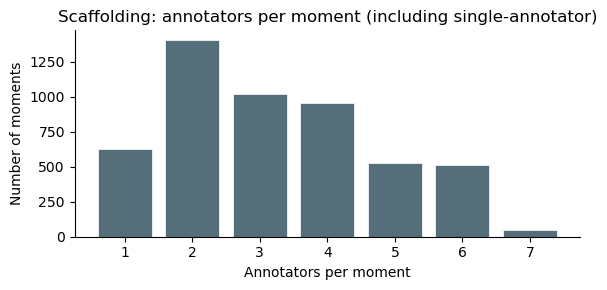

rapport: 5,226 key moments total
  Shared moments (2+ annotators): 914  (89.1% of moments are in a shared moment)
  Annotators per moment — mean: 5.3, median: 5, max: 11


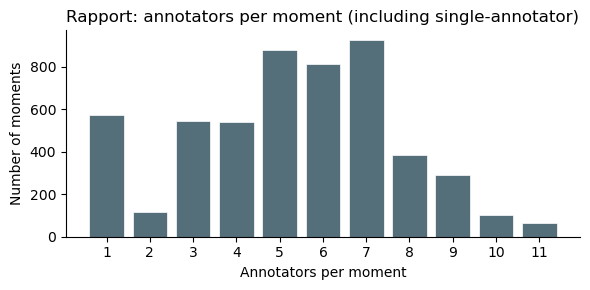


---- Overall IAA ----
scaffolding: overall Krippendorff's α = 0.2174 (1478 units)
rapport: overall Krippendorff's α = 0.2486 (914 units)


In [251]:
# Total moments per type (from the already-loaded counts)
total_moments = {
    ann_type: sum(sum(tc[ann_type].values()) for tc in counts.values() if ann_type in tc)
    for ann_type in ("scaffolding", "rapport")
}

for ann_type in ("scaffolding", "rapport"):
    total    = total_moments[ann_type]
    full_mat, _ = get_reliability_matrix(ann_type)
    n_units  = full_mat.shape[1] if full_mat.size > 0 else 0

    if n_units > 0:
        ann_per_unit = (~np.isnan(full_mat)).sum(axis=0).astype(int)
        n_in_multi   = int(ann_per_unit.sum())
    else:
        ann_per_unit = np.array([], dtype=int)
        n_in_multi   = 0

    # One entry per individual moment. Moments in a shared unit get the cluster
    # size as their value; moments not in any shared unit get 1.
    n_single  = total - n_in_multi
    full_dist = np.concatenate([
        np.repeat(ann_per_unit, ann_per_unit),
        np.ones(n_single, dtype=int),
    ])

    print(f"{ann_type}: {total:,} key moments total")
    print(f"  Shared moments (2+ annotators): {n_units:,}  "
          f"({100 * n_in_multi / total:.1f}% of moments are in a shared moment)")
    print(f"  Annotators per moment — "
          f"mean: {full_dist.mean():.1f}, "
          f"median: {int(np.median(full_dist))}, "
          f"max: {full_dist.max()}")

    fig, ax = plt.subplots(figsize=(6, 3))
    unique, cnts = np.unique(full_dist, return_counts=True)
    ax.bar(unique, cnts, color="#546e7a", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Annotators per moment")
    ax.set_ylabel("Number of moments")
    ax.set_title(f"{ann_type.capitalize()}: annotators per moment (including single-annotator)")
    ax.set_xticks(unique)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

print("\n---- Overall IAA ----")
for ann_type in ("scaffolding", "rapport"):
    full_mat, _ = get_reliability_matrix(ann_type)
    alpha   = compute_iaa(full_mat)
    n_units = full_mat.shape[1] if full_mat.size > 0 else 0
    print(f"{ann_type}: overall Krippendorff's α = {alpha} ({n_units} units)")


For **rapport**, moments typically get multiple (2+) annotations each. 

We can calculate the average effectiveness score per moment, averaged over all annotators who annotated that moment. Mapping: effective=1, partial=0, ineffective=-1. 

This gives a continuous sense of what moments tend be less effective, and which ones tend to be more effective. 

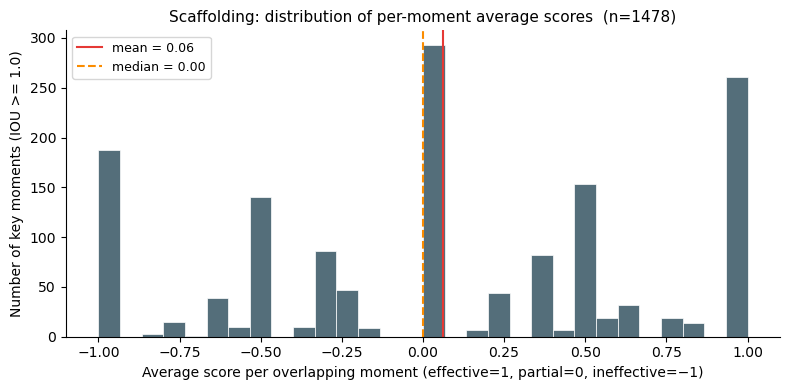

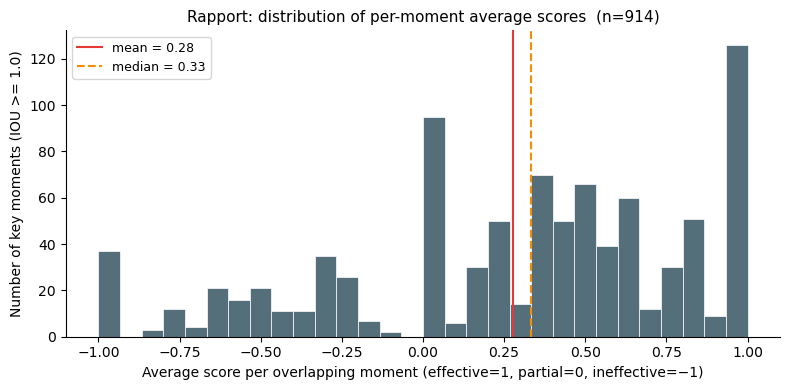

In [265]:
SCORE_MAP = {0: 1, 1: 0, 2: -1}  # ordinal code → score

for ann_type in ("scaffolding", "rapport"):
    full_mat, _ = get_reliability_matrix(ann_type)

    # Remap codes to scores (NaN stays NaN)
    # Fill NaN with 0 only for the cast, then restore NaN
    _safe = np.where(np.isnan(full_mat), 0, full_mat).astype(int)
    score_mat = np.where(np.isnan(full_mat), np.nan,
                        np.vectorize(SCORE_MAP.get)(_safe).astype(float))

    unit_means = np.nanmean(score_mat, axis=0)  # one value per unit

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(unit_means, bins=30, color="#546e7a", edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(unit_means), color="#e53935", linewidth=1.5,
            label=f"mean = {np.mean(unit_means):.2f}")
    ax.axvline(np.median(unit_means), color="#fb8c00", linewidth=1.5, linestyle="--",
            label=f"median = {np.median(unit_means):.2f}")
    ax.set_xlabel("Average score per overlapping moment (effective=1, partial=0, ineffective=−1)", fontsize=10)
    ax.set_ylabel(f"Number of key moments (IOU >= {IOU_THRESHOLD})", fontsize=10)
    ax.set_title(f"{ann_type.capitalize()}: distribution of per-moment average scores  (n={len(unit_means)})", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

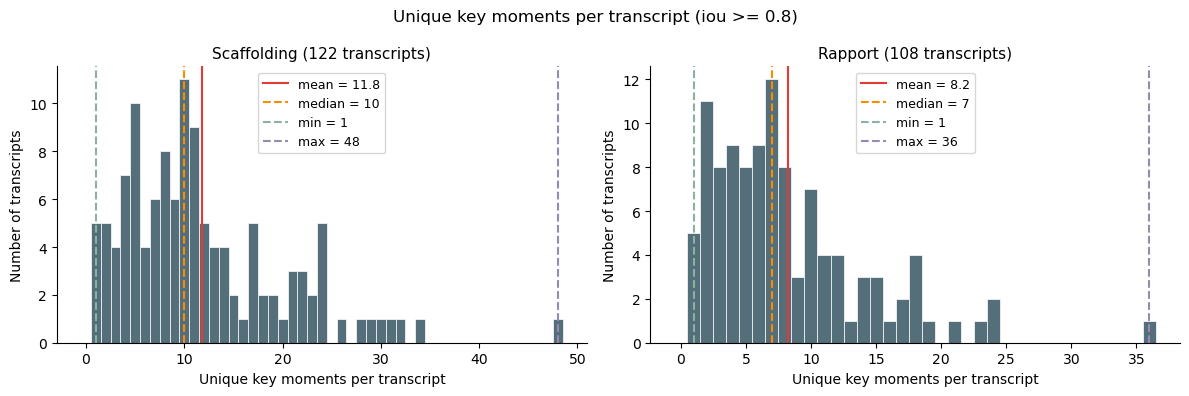

In [253]:
# histogram of number of key moments per transcript (annotator-agnostic, i.e. counting all moments from all annotators)
def _cluster_by_exact(moments):
    """Group moments that share the exact same (turn_start, turn_end) into a cluster."""
    clusters = defaultdict(list)
    for m in moments:
        clusters[(m["turn_start"], m["turn_end"])].append(m)
    return list(clusters.values())

unique_per_transcript = defaultdict(lambda: defaultdict(int))  # conv_id -> ann_type -> n_clusters

for f in GT_DIR.glob("*.json"):
    with open(f) as fp:
        d = json.load(fp)
    conv_id = d.get("conversation_id", f.stem)
    for ann_type in ("scaffolding", "rapport"):
        moments = [
            m for m in d.get("key_moments", [])
            if m.get("annotation_type") == ann_type
            and m.get("strategy_label") in VALID_LABELS
        ]
        if moments:
            moment_clust = _cluster_moments(moments, iou_threshold=0.8)  # or _cluster_by_exact(moments) for exact match
            unique_per_transcript[conv_id][ann_type] = len(moment_clust)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ann_type in zip(axes, ["scaffolding", "rapport"]):
    cnts = [c[ann_type] for c in unique_per_transcript.values() if ann_type in c]
    bins = range(0, max(cnts) + 2)
    ax.hist(cnts, bins=bins, color="#546e7a", edgecolor="white", linewidth=0.5, align="left")
    ax.axvline(np.mean(cnts), color="#e53935", linewidth=1.5,
               label=f"mean = {np.mean(cnts):.1f}")
    ax.axvline(np.median(cnts), color="#fb8c00", linewidth=1.5, linestyle="--",
               label=f"median = {int(np.median(cnts))}")
    ax.axvline(min(cnts), color="#8ab2a1", linewidth=1.5, linestyle="--",
               label=f"min = {int(min(cnts))}")
    ax.axvline(max(cnts), color="#978ab2", linewidth=1.5, linestyle="--",
               label=f"max = {int(max(cnts))}")  
    ax.set_xlabel("Unique key moments per transcript", fontsize=10)
    ax.set_ylabel("Number of transcripts", fontsize=10)
    ax.set_title(f"{ann_type.capitalize()} ({len(cnts)} transcripts)", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Unique key moments per transcript (iou >= 0.8)", fontsize=12)
plt.tight_layout()
plt.show()

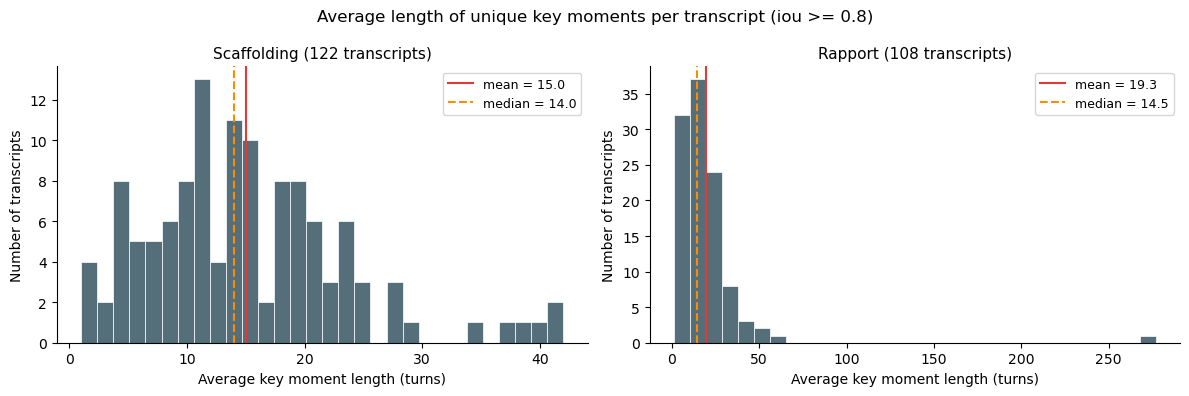

In [254]:
# histogram of average length of unique key moments (annotator-agnostic, i.e. counting all moments from all annotators)
avg_len_per_transcript = defaultdict(dict)  # conv_id -> ann_type -> mean cluster length (turns)

for f in GT_DIR.glob("*.json"):
    with open(f) as fp:
        d = json.load(fp)
    conv_id = d.get("conversation_id", f.stem)
    for ann_type in ("scaffolding", "rapport"):
        moments = [
            m for m in d.get("key_moments", [])
            if m.get("annotation_type") == ann_type
            and m.get("strategy_label") in VALID_LABELS
        ]
        if not moments:
            continue
        clusters = _cluster_moments(moments, iou_threshold=0.8)
        lengths = [
            max(m["turn_end"] for m in cl) - min(m["turn_start"] for m in cl) + 1
            for cl in clusters
        ]
        avg_len_per_transcript[conv_id][ann_type] = np.mean(lengths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ann_type in zip(axes, ["scaffolding", "rapport"]):
    avgs = [v[ann_type] for v in avg_len_per_transcript.values() if ann_type in v]
    ax.hist(avgs, bins=30, color="#546e7a", edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(avgs), color="#e53935", linewidth=1.5,
               label=f"mean = {np.mean(avgs):.1f}")
    ax.axvline(np.median(avgs), color="#fb8c00", linewidth=1.5, linestyle="--",
               label=f"median = {np.median(avgs):.1f}")
    ax.set_xlabel("Average key moment length (turns)", fontsize=10)
    ax.set_ylabel("Number of transcripts", fontsize=10)
    ax.set_title(f"{ann_type.capitalize()} ({len(avgs)} transcripts)", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Average length of unique key moments per transcript (iou >= 0.8)", fontsize=12)
plt.tight_layout()
plt.show()

# Overview of annotator trends

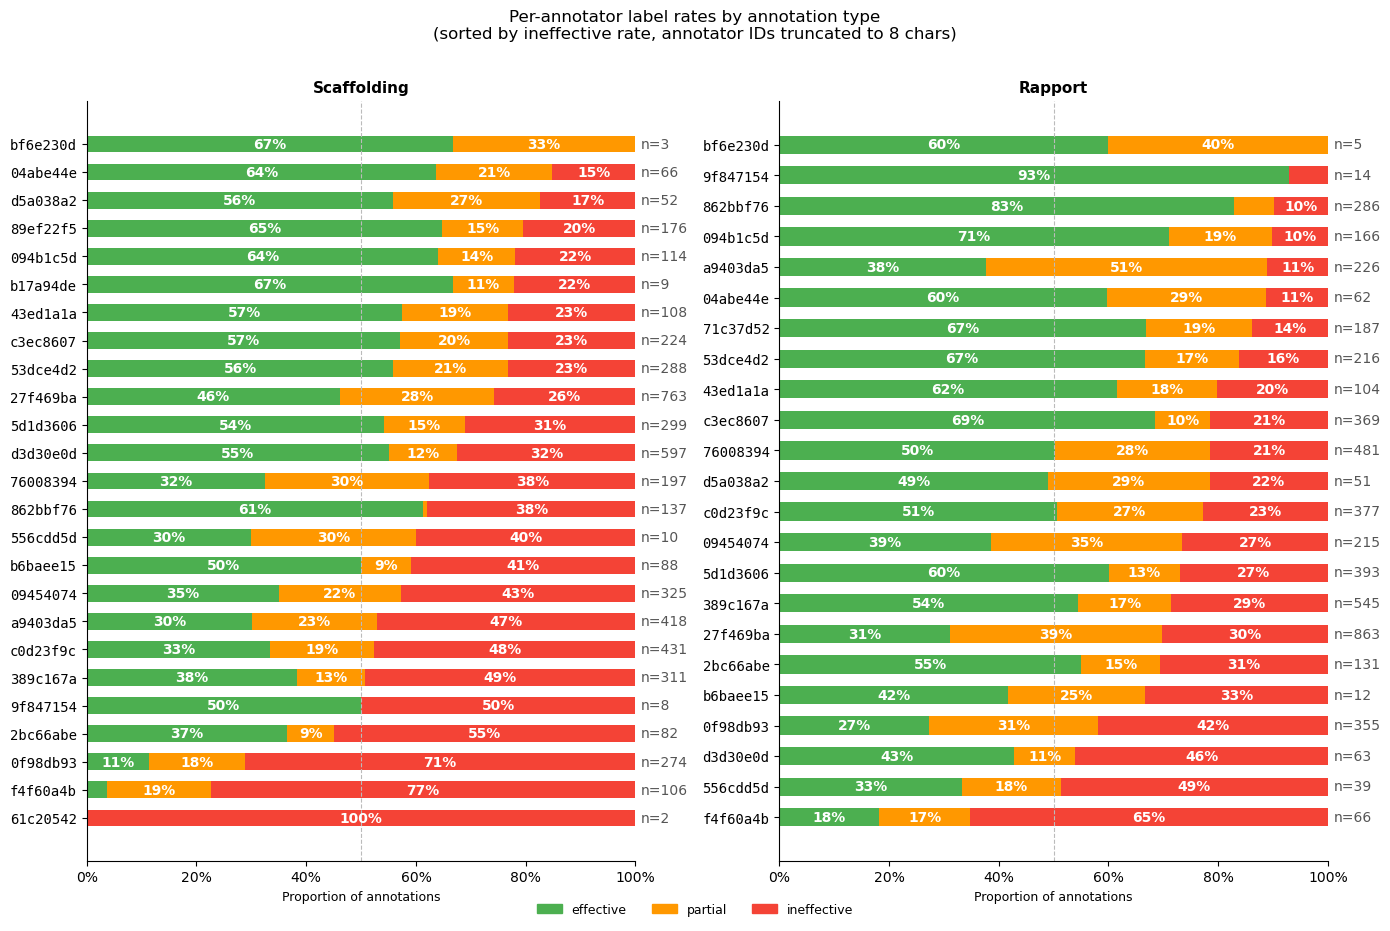

In [255]:
def make_rates_table(ann_type):
    """Return list of (short_id, full_id, rates_dict, total) sorted by ineffective rate desc."""
    rows = []
    for ann_id, type_counts in counts.items():
        if ann_type not in type_counts:
            continue
        c = type_counts[ann_type]
        total = sum(c.values())
        rates = {label: c.get(label, 0) / total for label in LABEL_ORDER}
        rows.append((ann_id[:8], ann_id, rates, total))
    rows.sort(key=lambda r: r[2]["ineffective"], reverse=True)
    return rows


def plot_rates(ann_type, ax):
    rows = make_rates_table(ann_type)
    if not rows:
        ax.set_visible(False)
        return

    short_ids = [r[0] for r in rows]
    totals    = [r[3] for r in rows]
    y = np.arange(len(rows))

    lefts = np.zeros(len(rows))
    for label in LABEL_ORDER:
        vals = np.array([r[2][label] for r in rows])
        bars = ax.barh(y, vals, left=lefts, color=COLORS[label], label=label, height=0.6)
        # Annotate segments ≥ 8% wide
        for bar, v in zip(bars, vals):
            if v >= 0.08:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0%}",
                    ha="center", va="center", fontsize=10, color="white", fontweight="bold"
                )
        lefts += vals

    # n= labels at the right edge
    for i, (_, _, _, n) in enumerate(rows):
        ax.text(1.01, i, f"n={n}", va="center", fontsize=10, color="#555")

    ax.set_yticks(y)
    ax.set_yticklabels(short_ids, fontsize=10, fontfamily="monospace")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Proportion of annotations", fontsize=9)
    ax.set_title(ann_type.capitalize(), fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.axvline(0.5, color="#bbb", linewidth=0.8, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(14, 9))

for ax, ann_type in zip(axes, ["scaffolding", "rapport"]):
    plot_rates(ann_type, ax)

legend_patches = [mpatches.Patch(color=COLORS[l], label=l) for l in LABEL_ORDER]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Per-annotator label rates by annotation type\n(sorted by ineffective rate, annotator IDs truncated to 8 chars)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Threshold-based profile creation

Threshold-based annotator grouping by ineffective rate. 

Annotators are assigned to groups based on their % of ineffective ratings.

Only annotators with > MIN_MOMENTS valid key moments are included.

Then, we calculate IAA (Krippendorff's alpha) for each profile. 

In [256]:
# --- Configure these ---
# these cutoffs are manually chosen based on distributions in previous plot in an attempt to get good IAA
SCAFFOLDING_CUTOFFS = [0.25, 0.55]   # e.g. [0.3, 0.6] → groups: <30%, 30–60%, ≥60%
RAPPORT_CUTOFFS = [0.2, 0.4]   # e.g. [0.3, 0.6] → groups: <30%, 30–60%, ≥60%
# -----------------------

def _threshold_annotator_vecs(ann_type):
    vecs = {}
    for ann_id, tc in counts.items():
        if ann_type not in tc:
            continue
        c     = tc[ann_type]
        total = sum(v for k, v in c.items() if k in VALID_LABELS)
        if total <= MIN_MOMENTS:
            continue
        vecs[ann_id] = {
            "ineffective": c.get("ineffective", 0) / total,
            "total":       total,
        }
    return vecs

# --- Overall IAA ---
print("---- Overall IAA (effectiveness) ----")
for ann_type in ("scaffolding", "rapport"):
    full_mat, _ = get_reliability_matrix(ann_type)
    alpha   = compute_iaa(full_mat)
    n_units = full_mat.shape[1] if full_mat.size > 0 else 0
    print(f"  {ann_type}: Krippendorff's α = {alpha}  ({n_units} units)")

# --- Threshold-based groups ---
for ann_type in ["scaffolding", "rapport"]:
    if ann_type == "scaffolding":
        cutoffs = SCAFFOLDING_CUTOFFS
    else:
        cutoffs = RAPPORT_CUTOFFS
    cutoffs = [0.0] + sorted(cutoffs) + [1.01]
    vecs              = _threshold_annotator_vecs(ann_type)
    full_mat, all_ann = get_reliability_matrix(ann_type)

    cutoff_labels = " | ".join(
        f"[{cutoffs[i]:.0%}, {'100%' if cutoffs[i+1] > 1 else f'{cutoffs[i+1]:.0%}'})"
        for i in range(len(cutoffs) - 1)
    )
    print(f"\n{'='*60}")
    print(f"{ann_type.upper()}  (MIN_MOMENTS > {MIN_MOMENTS}, IoU >= {IOU_THRESHOLD})")
    print(f"Groups by ineffective rate: {cutoff_labels}")

    for i in range(len(cutoffs) - 1):
        lo, hi      = cutoffs[i], cutoffs[i + 1]
        hi_label    = "100%" if hi > 1.0 else f"{hi:.0%}"
        group_label = f"[{lo:.0%}, {hi_label})"
        members     = [a for a, v in vecs.items() if lo <= v["ineffective"] < hi]

        if not members:
            print(f"\n  Group {i+1} {group_label}: no annotators")
            continue

        mat     = submatrix_for(full_mat, all_ann, members)
        alpha   = compute_iaa(mat)
        n_units = mat.shape[1] if mat is not None else 0

        alpha_str       = f"{alpha:.4f}" if alpha is not None else "n/a (no shared units)"
        members_display = ", ".join(sorted(a[:8] for a in members))

        print(f"\n  Group {i+1} {group_label}: {len(members)} annotators, {n_units} overlapping moments")
        print(f"    Annotators:       {members_display}")
        print(f"    Krippendorff's α: {alpha_str}")


---- Overall IAA (effectiveness) ----
  scaffolding: Krippendorff's α = 0.2174  (1478 units)
  rapport: Krippendorff's α = 0.2486  (914 units)

SCAFFOLDING  (MIN_MOMENTS > 50, IoU >= 1.0)
Groups by ineffective rate: [0%, 25%) | [25%, 55%) | [55%, 100%)

  Group 1 [0%, 25%): 7 annotators, 188 overlapping moments
    Annotators:       04abe44e, 094b1c5d, 43ed1a1a, 53dce4d2, 89ef22f5, c3ec8607, d5a038a2
    Krippendorff's α: 0.2886

  Group 2 [25%, 55%): 11 annotators, 1046 overlapping moments
    Annotators:       09454074, 27f469ba, 2bc66abe, 389c167a, 5d1d3606, 76008394, 862bbf76, a9403da5, b6baee15, c0d23f9c, d3d30e0d
    Krippendorff's α: 0.2529

  Group 3 [55%, 100%): 2 annotators, 11 overlapping moments
    Annotators:       0f98db93, f4f60a4b
    Krippendorff's α: 0.5909

RAPPORT  (MIN_MOMENTS > 50, IoU >= 1.0)
Groups by ineffective rate: [0%, 20%) | [20%, 40%) | [40%, 100%)

  Group 1 [0%, 20%): 6 annotators, 318 overlapping moments
    Annotators:       04abe44e, 094b1c5d, 53dce

# What if we derived profiles by clustering? 

K-medoids clustering of annotator vectors using Earth Mover's Distance (EMD). 

Each annotator is represented as (effective%, partial%, ineffective%), normalised over those three labels only (unclear excluded).

Only annotators with >= MIN_MOMENTS valid key moments are included. EMD treats the label vector as a probability distribution over the ordinal scale effective=0, partial=1, ineffective=2. This respects the ordering between labels, unlike Euclidean or cosine distance.

K-medoids is used because medoids must be actual data points (required when using a custom distance matrix).

**Takeaway**: we don't gain much from this more complicated approach over threshold-based profiles.

scaffolding: 20 annotators with >= 50 moments
rapport: 19 annotators with >= 50 moments


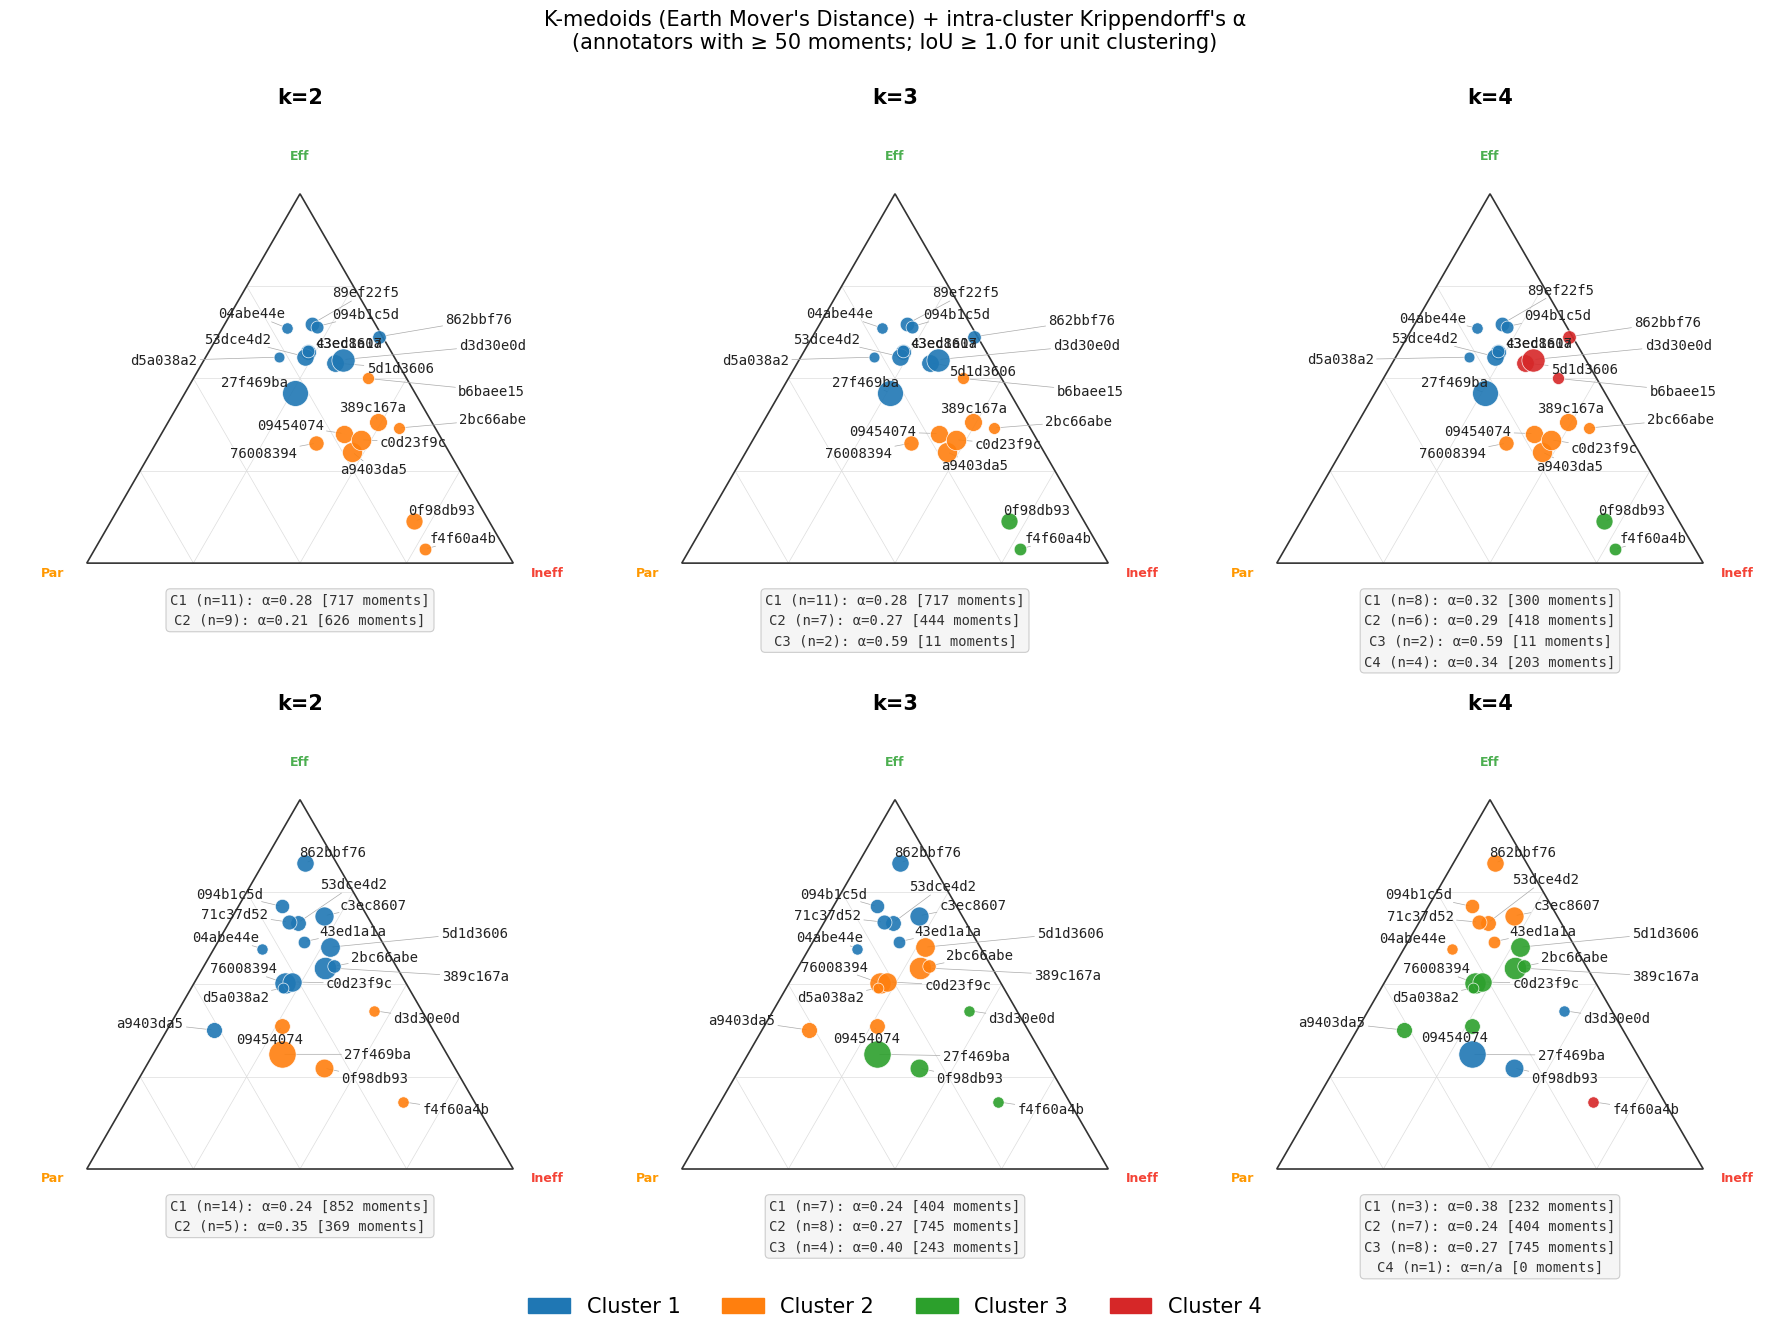

In [257]:
K_VALUES        = [2, 3, 4]
N_INIT          = 20
CLUSTER_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

SQRT3_2           = np.sqrt(3) / 2
CORNERS           = np.array([[0.5, SQRT3_2], [0.0, 0.0], [1.0, 0.0]])
ORDINAL_POSITIONS = [0, 1, 2]


def emd(p, q):
    return wasserstein_distance(ORDINAL_POSITIONS, ORDINAL_POSITIONS,
                                u_weights=p, v_weights=q)


def pairwise_emd(vecs):
    n = len(vecs)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = emd(vecs[i], vecs[j])
            D[i, j] = D[j, i] = d
    return D


def kmedoids_once(D, k, rng):
    n       = D.shape[0]
    medoids = [rng.integers(n)]
    for _ in range(k - 1):
        dists = np.min(D[:, medoids], axis=1)
        probs = dists / dists.sum()
        medoids.append(rng.choice(n, p=probs))
    medoids = list(dict.fromkeys(medoids))
    for _ in range(100):
        labels      = np.argmin(D[:, medoids], axis=1)
        new_medoids = []
        for ci in range(k):
            members = np.where(labels == ci)[0]
            if len(members) == 0:
                new_medoids.append(medoids[ci])
            else:
                new_medoids.append(members[np.argmin(D[np.ix_(members, members)].sum(axis=1))])
        if new_medoids == medoids:
            break
        medoids = new_medoids
    labels     = np.argmin(D[:, medoids], axis=1)
    total_cost = sum(D[i, medoids[labels[i]]] for i in range(n))
    return labels, total_cost


def kmedoids(D, k, n_init=N_INIT, seed=42):
    rng        = np.random.default_rng(seed)
    best_labels, best_cost = None, np.inf
    for _ in range(n_init):
        labels, cost = kmedoids_once(D, k, rng)
        if cost < best_cost:
            best_cost, best_labels = cost, labels
    return best_labels


def build_annotator_vectors(ann_type):
    vecs = {}
    for ann_id, type_counts in counts.items():
        if ann_type not in type_counts:
            continue
        c     = type_counts[ann_type]
        total = sum(v for k, v in c.items() if k in VALID_LABELS)
        if total < MIN_MOMENTS:
            continue
        vecs[ann_id] = np.array([
            c.get("effective",   0) / total,
            c.get("partial",     0) / total,
            c.get("ineffective", 0) / total,
        ])
    return vecs


def to_cartesian(eff, partial, ineff):
    return 0.5 * eff + ineff, eff * SQRT3_2


def draw_ternary_frame(ax):
    ax.add_patch(plt.Polygon(CORNERS, fill=False, edgecolor="#333", linewidth=1.2))
    for t in [0.25, 0.50, 0.75]:
        for p1, p2 in [
            (to_cartesian(t, 1-t, 0), to_cartesian(t, 0, 1-t)),
            (to_cartesian(1-t, t, 0), to_cartesian(0, t, 1-t)),
            (to_cartesian(1-t, 0, t), to_cartesian(0, 1-t, t)),
        ]:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="#ddd", linewidth=0.5, zorder=0)
    off = 0.08
    ax.text(CORNERS[0][0], CORNERS[0][1] + off, "Eff",   ha="center", fontsize=9,
            fontweight="bold", color=COLORS["effective"])
    ax.text(CORNERS[1][0] - off, CORNERS[1][1] - 0.03, "Par",   ha="center", fontsize=9,
            fontweight="bold", color=COLORS["partial"])
    ax.text(CORNERS[2][0] + off, CORNERS[2][1] - 0.03, "Ineff", ha="center", fontsize=9,
            fontweight="bold", color=COLORS["ineffective"])


def plot_clustered_ternary(ann_type, k, vecs, assignment, full_mat, all_ann, ax):
    draw_ternary_frame(ax)

    ann_ids  = list(vecs.keys())
    clusters = [assignment[a] for a in ann_ids]
    xs, ys, texts = [], [], []

    for ann_id, cluster_id in zip(ann_ids, clusters):
        eff, par, ineff = vecs[ann_id]
        x, y = to_cartesian(eff, par, ineff)
        xs.append(x); ys.append(y)
        n_total = sum(v for lbl, v in counts[ann_id][ann_type].items() if lbl in VALID_LABELS)
        ax.scatter(x, y, s=n_total * 0.4 + 40, color=CLUSTER_PALETTE[cluster_id],
                   alpha=0.9, zorder=3, edgecolors="white", linewidths=0.5)
        t = ax.text(x, y, ann_id[:8], ha="center", va="bottom",
                    fontsize=10, fontfamily="monospace", color="#222", zorder=4)
        texts.append(t)

    adjust_text(texts, x=xs, y=ys, ax=ax, expand=(1.4, 1.6),
                arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.5))

    kappa_lines = []
    for cid in range(k):
        members  = [a for a, cl in zip(ann_ids, clusters) if cl == cid]
        mat      = submatrix_for(full_mat, all_ann, members)
        alpha    = compute_iaa(mat)
        n_units  = mat.shape[1] if mat is not None else 0
        alpha_str = f"{alpha:.2f}" if alpha is not None else "n/a"
        kappa_lines.append(f"C{cid+1} (n={len(members)}): α={alpha_str} [{n_units} moments]")

    ax.text(0.5, -0.07, "\n".join(kappa_lines),
            ha="center", va="top", fontsize=10, fontfamily="monospace",
            color="#333", linespacing=1.6,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#f5f5f5",
                      edgecolor="#ccc", linewidth=0.8))

    ax.set_xlim(-0.18, 1.18)
    ax.set_ylim(-0.28, SQRT3_2 + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"k={k}", fontsize=15, fontweight="bold", pad=10)


fig, axes = plt.subplots(2, len(K_VALUES), figsize=(6 * len(K_VALUES), 13))

for row, ann_type in enumerate(["scaffolding", "rapport"]):
    vecs          = build_annotator_vectors(ann_type)
    full_mat, all_ann = get_reliability_matrix(ann_type)
    ann_ids       = list(vecs.keys())
    X             = np.array([vecs[a] for a in ann_ids])
    D             = pairwise_emd(X)

    print(f"{ann_type}: {len(ann_ids)} annotators with >= {MIN_MOMENTS} moments")

    for col, k in enumerate(K_VALUES):
        ax          = axes[row][col]
        effective_k = min(k, len(ann_ids))
        labels      = kmedoids(D, effective_k)
        assignment  = {a: int(labels[i]) for i, a in enumerate(ann_ids)}
        plot_clustered_ternary(ann_type, effective_k, vecs, assignment, full_mat, all_ann, ax)
        if col == 0:
            ax.set_ylabel(ann_type.capitalize(), fontsize=15, fontweight="bold", labelpad=70)

fig.suptitle(
    f"K-medoids (Earth Mover's Distance) + intra-cluster Krippendorff's α\n"
    f"(annotators with ≥ {MIN_MOMENTS} moments; IoU ≥ {IOU_THRESHOLD} for unit clustering)",
    fontsize=15, y=1.01,
)
legend_handles = [mpatches.Patch(color=CLUSTER_PALETTE[i], label=f"Cluster {i+1}")
                  for i in range(max(K_VALUES))]
fig.legend(handles=legend_handles, loc="lower center", ncol=max(K_VALUES),
           fontsize=15, frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.show()


# Individual annotators' IAA

Pairwise IAA ranking: Krippendorff's α (ordinal) for all annotator pairs, if they have at least MIN_OVERLAP IoU-clustered moments.

I also tried plotting a network graph based on IAA but it was a mess so I removed it.

In [258]:
MIN_OVERLAP = 50

for ann_type in ["scaffolding", "rapport"]:
    full_mat, all_ann = get_reliability_matrix(ann_type)
    if full_mat.size == 0:
        print(f"{ann_type}: no data")
        continue

    rows = []
    for i, a1 in enumerate(all_ann):
        for a2 in all_ann[i + 1:]:
            mat = submatrix_for(full_mat, all_ann, [a1, a2])
            if mat is None:
                continue
            n_units = mat.shape[1]
            if n_units < MIN_OVERLAP:
                continue
            alpha = compute_iaa(mat)
            if alpha is None or np.isnan(alpha):
                continue
            rows.append({
                "annotator A": a1[:8],
                "annotator B": a2[:8],
                "α":           alpha,
                "n units":     n_units,
            })

    df = (pd.DataFrame(rows)
            .sort_values("α", ascending=False)
            .reset_index(drop=True))
    df.index += 1
    df.index.name = "rank"

    print(f"\n{ann_type.upper()} — Krippendorff's α (n >= {MIN_OVERLAP} shared moments, {len(df)} pairs)")
    print(df.to_string())



SCAFFOLDING — Krippendorff's α (n >= 50 shared moments, 39 pairs)
     annotator A annotator B       α  n units
rank                                         
1       c0d23f9c    d3d30e0d  0.4854      113
2       27f469ba    c3ec8607  0.4519       72
3       389c167a    a9403da5  0.4120       66
4       27f469ba    89ef22f5  0.3955       60
5       5d1d3606    a9403da5  0.3764       83
6       76008394    d3d30e0d  0.3645       86
7       389c167a    c0d23f9c  0.3412       88
8       5d1d3606    d3d30e0d  0.3287      113
9       27f469ba    53dce4d2  0.3237      119
10      53dce4d2    d3d30e0d  0.3094       87
11      a9403da5    c0d23f9c  0.3045      104
12      862bbf76    d3d30e0d  0.3005       51
13      09454074    c0d23f9c  0.2962      116
14      389c167a    d3d30e0d  0.2797       77
15      27f469ba    d3d30e0d  0.2736      128
16      27f469ba    862bbf76  0.2719       77
17      09454074    d3d30e0d  0.2445      127
18      53dce4d2    c0d23f9c  0.2235       91
19      09454

# Situation Annotations

In [259]:
# How many unique scaffolding moments have situation_label scaffolding = yes, no, unclear and rigor = yes, no, unclear?

scaf_counts  = Counter()
rigor_counts = Counter()
cross_counts = Counter()

for f in GT_DIR.glob("*.json"):
    with open(f) as fp:
        d = json.load(fp)
    for m in d.get("key_moments", []):
        if m.get("annotation_type") != "scaffolding":
            continue
        sl = m.get("situation_label")
        if sl is None:
            continue
        scaf_label  = sl.get("scaffolding", "missing")
        rigor_label = sl.get("rigor",       "missing")
        scaf_counts[scaf_label]  += 1
        rigor_counts[rigor_label] += 1
        cross_counts[(scaf_label, rigor_label)] += 1

LABEL_ORDER_SIT = ["yes", "no", "unclear", "no_mention"]

print(f"=== Scaffolding moments by situation_label (n={sum(scaf_counts.values())}) ===\n")

print("situation_label.scaffolding:")
for lbl in LABEL_ORDER_SIT:
    print(f"  {lbl:12s}: {scaf_counts.get(lbl, 0):4d}")
print(f"  {'TOTAL':12s}: {sum(scaf_counts.values()):4d}")

print("\nsituation_label.rigor:")
for lbl in LABEL_ORDER_SIT:
    print(f"  {lbl:12s}: {rigor_counts.get(lbl, 0):4d}")
print(f"  {'TOTAL':12s}: {sum(rigor_counts.values()):4d}")

print("\nCross-tabulation (scaffolding × rigor):")
header = f"{'scaffolding \\ rigor':20s}" + "".join(f"{lbl:>12s}" for lbl in LABEL_ORDER_SIT) + f"{'TOTAL':>8s}"
print(header)
for s_lbl in LABEL_ORDER_SIT:
    row_vals = [cross_counts.get((s_lbl, r_lbl), 0) for r_lbl in LABEL_ORDER_SIT]
    print(f"  {s_lbl:18s}" + "".join(f"{v:12d}" for v in row_vals) + f"{sum(row_vals):8d}")
col_totals = [sum(cross_counts.get((s, r), 0) for s in LABEL_ORDER_SIT) for r in LABEL_ORDER_SIT]
print(f"  {'TOTAL':18s}" + "".join(f"{v:12d}" for v in col_totals) + f"{sum(col_totals):8d}")


=== Scaffolding moments by situation_label (n=5096) ===

situation_label.scaffolding:
  yes         : 2405
  no          :  815
  unclear     :   97
  no_mention  : 1779
  TOTAL       : 5096

situation_label.rigor:
  yes         : 1437
  no          :  408
  unclear     :   44
  no_mention  : 3207
  TOTAL       : 5096

Cross-tabulation (scaffolding × rigor):
scaffolding \ rigor          yes          no     unclear  no_mention   TOTAL
  yes                        103          23           2        2277    2405
  no                          93         331           4         387     815
  unclear                     11           2          26          58      97
  no_mention                1230          52          12         485    1779
  TOTAL                     1437         408          44        3207    5096


(scaffolding, rigor) binary tuple: Krippendorff's α = 0.2672  (1355 clusters with 2+ valid annotators)


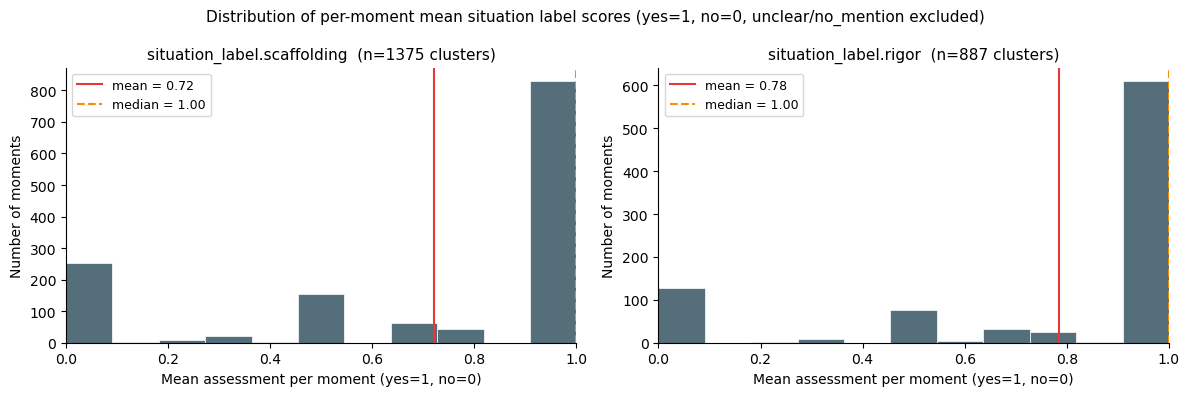

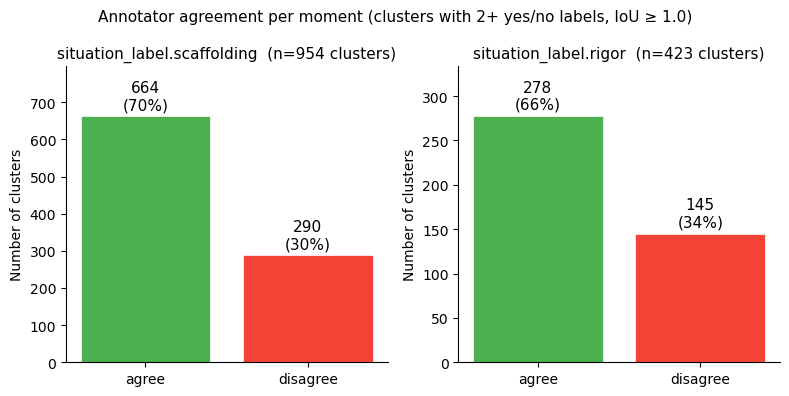

In [264]:
# Calculate Krippendorff's alpha at the tuple level:
#   1. Exclude annotators whose (scaffolding, rigor) is both no_mention
#   2. Remap remaining no_mention → no (binary yes/no labels)
#   3. Compute alpha on the joint (scaffolding, rigor) tuple (nominal)

def _sit(val):
    """Normalise a situation_label slot value: remap unclear → no_mention."""
    return "no_mention" if val == "unclear" else (val or "missing")


def build_binary_tuple_matrix():
    """
    Reliability matrix where each label is the binary (scaf, rigor) tuple after
    excluding both=no_mention annotators and remapping no_mention → no.
    Only clusters with 2+ valid annotators contribute.
    """
    all_tuples   = set()
    cluster_data = []

    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
        for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
            seen_ann = set()
            unit     = {}
            for m in cluster:
                ann_id = m["annotator_id"]
                if ann_id in seen_ann:
                    continue
                seen_ann.add(ann_id)
                sl    = m.get("situation_label") or {}
                scaf  = _sit(sl.get("scaffolding"))
                rigor = _sit(sl.get("rigor"))
                if scaf == "no_mention" and rigor == "no_mention":
                    continue
                scaf  = "no" if scaf  == "no_mention" else scaf
                rigor = "no" if rigor == "no_mention" else rigor
                tpl          = (scaf, rigor)
                unit[ann_id] = tpl
                all_tuples.add(tpl)
            if len(unit) >= 2:
                cluster_data.append(unit)

    if not cluster_data:
        return np.empty((0, 0)), []

    tpl_idx = {tpl: i for i, tpl in enumerate(sorted(all_tuples))}
    all_ann = sorted({a for u in cluster_data for a in u})
    ann_idx = {a: i for i, a in enumerate(all_ann)}
    matrix  = np.full((len(all_ann), len(cluster_data)), np.nan)
    for j, unit in enumerate(cluster_data):
        for ann_id, tpl in unit.items():
            matrix[ann_idx[ann_id], j] = tpl_idx[tpl]
    return matrix, all_ann


def build_situation_label_matrix(subfield):
    """Reliability matrix for a binary subfield (yes=0, no=1), 2+ yes/no labels per cluster."""
    val_idx = {"yes": 0, "no": 1}
    units   = []
    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
        for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
            seen = {}
            for m in cluster:
                ann_id = m["annotator_id"]
                val    = _sit((m.get("situation_label") or {}).get(subfield))
                if val in val_idx and ann_id not in seen:
                    seen[ann_id] = val_idx[val]
            if len(seen) >= 2:
                units.append(seen)
    if not units:
        return np.empty((0, 0)), []
    all_ann = sorted({a for u in units for a in u})
    ann_idx = {a: i for i, a in enumerate(all_ann)}
    matrix  = np.full((len(all_ann), len(units)), np.nan)
    for j, unit in enumerate(units):
        for ann_id, code in unit.items():
            matrix[ann_idx[ann_id], j] = code
    return matrix, all_ann


def cluster_means_for(subfield):
    """Per-cluster mean score (yes=1, no=0) over clusters with at least 1 yes/no label."""
    score_map = {"yes": 1.0, "no": 0.0}
    means     = []
    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
        for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
            scores   = []
            seen_ann = set()
            for m in cluster:
                ann_id = m["annotator_id"]
                val    = _sit((m.get("situation_label") or {}).get(subfield))
                if val in score_map and ann_id not in seen_ann:
                    scores.append(score_map[val])
                    seen_ann.add(ann_id)
            if scores:
                means.append(np.mean(scores))
    return np.array(means)


def agreement_counts_for(subfield):
    """Count agree/disagree across clusters with 2+ yes/no labels for subfield."""
    result = Counter()
    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
        for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
            seen = {}
            for m in cluster:
                ann_id = m["annotator_id"]
                if ann_id not in seen:
                    seen[ann_id] = m
            votes = [
                _sit((m.get("situation_label") or {}).get(subfield))
                for m in seen.values()
                if _sit((m.get("situation_label") or {}).get(subfield)) in ("yes", "no")
            ]
            if len(votes) >= 2:
                result["agree" if len(set(votes)) == 1 else "disagree"] += 1
    return result


def cluster_any_yes_counts():
    """Count clusters by whether ≥1 annotator said yes for scaffolding and/or rigor.
    Applies the same both=no_mention exclusion as the confusion matrix."""
    result = Counter()
    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
        for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
            seen_ann      = set()
            scaf_any_yes  = False
            rigor_any_yes = False
            has_valid     = False
            for m in cluster:
                ann_id = m["annotator_id"]
                if ann_id in seen_ann:
                    continue
                seen_ann.add(ann_id)
                sl    = m.get("situation_label") or {}
                scaf  = _sit(sl.get("scaffolding"))
                rigor = _sit(sl.get("rigor"))
                if scaf == "no_mention" and rigor == "no_mention":
                    continue  # same exclusion as confusion matrix
                has_valid = True
                if scaf  == "yes": scaf_any_yes  = True
                if rigor == "yes": rigor_any_yes = True
            if has_valid:
                result[(scaf_any_yes, rigor_any_yes)] += 1
    return result


# --- Alpha on binary (scaffolding, rigor) tuple ---
mat, _  = build_binary_tuple_matrix()
n_units = mat.shape[1] if mat.size > 0 else 0
try:
    alpha = round(krippendorff.alpha(reliability_data=mat, level_of_measurement="nominal"), 4)
except ValueError:
    alpha = 1.0
print(f"(scaffolding, rigor) binary tuple: Krippendorff's α = {alpha}  "
      f"({n_units} clusters with 2+ valid annotators)")

# --- Distribution of per-moment mean scores ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, subfield in zip(axes, ("scaffolding", "rigor")):
    means = cluster_means_for(subfield)
    ax.hist(means, bins=np.linspace(0, 1, 12), color="#546e7a", edgecolor="white", linewidth=0.5)
    ax.axvline(means.mean(),     color="#e53935", linewidth=1.5, label=f"mean = {means.mean():.2f}")
    ax.axvline(np.median(means), color="#fb8c00", linewidth=1.5, linestyle="--",
               label=f"median = {np.median(means):.2f}")
    ax.set_xlabel("Mean assessment per moment (yes=1, no=0)", fontsize=10)
    ax.set_ylabel("Number of moments", fontsize=10)
    ax.set_title(f"situation_label.{subfield}  (n={len(means)} clusters)", fontsize=11)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Distribution of per-moment mean situation label scores (yes=1, no=0, unclear/no_mention excluded)",
             fontsize=11)
plt.tight_layout()
plt.show()

# --- Agree / disagree breakdown ---
AGREE_ORDER  = ["agree", "disagree"]
AGREE_COLORS = {"agree": "#4caf50", "disagree": "#f44336"}

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, subfield in zip(axes, ("scaffolding", "rigor")):
    agree_counts = agreement_counts_for(subfield)
    total        = sum(agree_counts.values())
    vals         = [agree_counts.get(cat, 0) for cat in AGREE_ORDER]
    bars         = ax.bar(AGREE_ORDER, vals,
                          color=[AGREE_COLORS[c] for c in AGREE_ORDER],
                          edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        pct = 100 * v / total if total else 0
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{v}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=11)
    ax.set_ylabel("Number of clusters", fontsize=10)
    ax.set_title(f"situation_label.{subfield}  (n={total} clusters)", fontsize=11)
    ax.set_ylim(0, max(vals) * 1.2)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle(f"Annotator agreement per moment (clusters with 2+ yes/no labels, IoU ≥ {IOU_THRESHOLD})", fontsize=11)
plt.tight_layout()
plt.show()

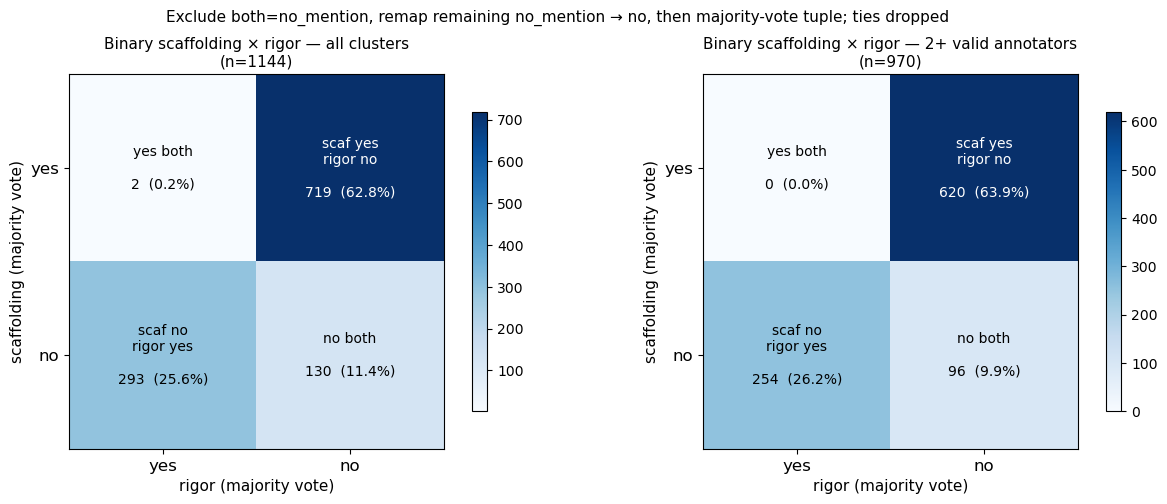

All clusters (n=1144):
  yes/yes (both):            2  (0.2%)
  mixed (one yes/one no): 1012  (88.5%)
  no/no  (both):           130  (11.4%)

2+ valid annotators (n=970):
  yes/yes (both):            0  (0.0%)
  mixed (one yes/one no):  874  (90.1%)
  no/no  (both):            96  (9.9%)



In [ ]:
# Exclude annotations where both scaffolding and rigor are no_mention.
# Remap no_mention → no for either subfield, giving binary yes/no labels.
# Majority-vote the joint (scaffolding, rigor) tuple, then count clusters by outcome.

def build_binary_conf_counts(min_valid=1):
    """
    For each cluster:
    1. drop annotators whose (scaf, rigor) tuple is both no_mention
    2. remap remaining no_mention → no (binary yes/no)
    3. take majority vote of the resulting tuple
    """
    result = Counter()
    for f in GT_DIR.glob("*.json"):
        with open(f) as fp:
            d = json.load(fp)
        moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
        for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
            seen_ann = set()
            tuples   = []
            for m in cluster:
                ann_id = m["annotator_id"]
                if ann_id in seen_ann:
                    continue
                seen_ann.add(ann_id)
                sl    = m.get("situation_label") or {}
                scaf  = _sit(sl.get("scaffolding"))
                rigor = _sit(sl.get("rigor"))
                if scaf == "no_mention" and rigor == "no_mention":
                    continue  # step 1: exclude
                scaf  = "no" if scaf  == "no_mention" else scaf  # step 2: remap
                rigor = "no" if rigor == "no_mention" else rigor
                tuples.append((scaf, rigor))
            if len(tuples) < min_valid:
                continue
            winner = majority_vote_tuple(tuples)
            if winner:
                result[winner] += 1
    return result


BINARY_ORDER = ["yes", "no"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, min_valid, subtitle in [
    (axes[0], 1, "all clusters"),
    (axes[1], 2, "2+ valid annotators"),
]:
    conf_counts = build_binary_conf_counts(min_valid=min_valid)
    conf_matrix = np.array([
        [conf_counts[(r, c)] for c in BINARY_ORDER]
        for r in BINARY_ORDER
    ])
    total = conf_matrix.sum()

    category_labels = [["yes both", "scaf yes\nrigor no"],
                       ["scaf no\nrigor yes", "no both"]]

    im = ax.imshow(conf_matrix, cmap="Blues")
    ax.set_xticks(range(2)); ax.set_yticks(range(2))
    ax.set_xticklabels(BINARY_ORDER, fontsize=12)
    ax.set_yticklabels(BINARY_ORDER, fontsize=12)
    ax.set_xlabel("rigor (majority vote)", fontsize=11)
    ax.set_ylabel("scaffolding (majority vote)", fontsize=11)
    ax.set_title(f"Binary scaffolding × rigor — {subtitle}\n(n={total})", fontsize=11)
    for i in range(2):
        for j in range(2):
            n         = conf_matrix[i, j]
            pct       = 100 * n / total if total else 0
            txt_color = "white" if n > conf_matrix.max() * 0.6 else "black"
            ax.text(j, i, f"{category_labels[i][j]}\n\n{n}  ({pct:.1f}%)",
                    ha="center", va="center", fontsize=10, color=txt_color)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Exclude both=no_mention, remap remaining no_mention → no, then majority-vote tuple; ties dropped",
             fontsize=11)
plt.tight_layout()
plt.show()

# summary counts
for label, min_valid in [("All clusters", 1), ("2+ valid annotators", 2)]:
    cc    = build_binary_conf_counts(min_valid=min_valid)
    total = sum(cc.values())
    yes_both = cc[("yes", "yes")]
    no_both  = cc[("no",  "no")]
    mixed    = cc[("yes", "no")] + cc[("no", "yes")]
    print(f"{label} (n={total}):")
    print(f"  yes/yes (both):         {yes_both:4d}  ({100*yes_both/total:.1f}%)")
    print(f"  mixed (one yes/one no): {mixed:4d}  ({100*mixed/total:.1f}%)")
    print(f"  no/no  (both):          {no_both:4d}  ({100*no_both/total:.1f}%)")
    print()

In [262]:
# N_DISAGREE_EXAMPLES = 8

# SLOT_COLORS = {"yes": "#2e7d32", "no": "#b71c1c", "no_mention": "#888"}


# def find_joint_disagreements():
#     """Return clusters where 2+ annotators gave different (scaffolding, rigor) tuples,
#     after remapping unclear → no_mention and excluding tuples with no yes/no slot."""
#     results = []
#     for f in GT_DIR.glob("*.json"):
#         with open(f) as fp:
#             d = json.load(fp)
#         conv_id = d.get("conversation_id", f.stem)
#         moments = [m for m in d.get("key_moments", []) if m.get("annotation_type") == "scaffolding"]
#         for cluster in _cluster_moments(moments, iou_threshold=IOU_THRESHOLD):
#             seen = {}
#             for m in cluster:
#                 ann_id = m["annotator_id"]
#                 if ann_id not in seen:
#                     seen[ann_id] = m
#             valid = {}
#             for ann_id, m in seen.items():
#                 sl    = m.get("situation_label") or {}
#                 scaf  = _sit(sl.get("scaffolding"))
#                 rigor = _sit(sl.get("rigor"))
#                 if scaf in ("yes", "no") or rigor in ("yes", "no"):
#                     valid[ann_id] = {"moment": m, "scaf": scaf, "rigor": rigor}
#             tuples = {ann_id: (v["scaf"], v["rigor"]) for ann_id, v in valid.items()}
#             if len(tuples) >= 2 and len(set(tuples.values())) > 1:
#                 results.append({"conv_id": conv_id, "annotations": valid})
#     return results


# def _badge(val):
#     color = SLOT_COLORS.get(val, "#555")
#     return (f'<span style="background:{color};color:white;padding:1px 7px;'
#             f'border-radius:3px;font-size:12px;font-weight:bold">{val}</span>')


# def render_joint_disagreements(examples):
#     n_shown = min(N_DISAGREE_EXAMPLES, len(examples))
#     blocks  = [
#         f"<h3 style='font-family:sans-serif'>(scaffolding, rigor) tuple disagreements "
#         f"({len(examples)} total, showing {n_shown})</h3>"
#     ]
#     for ex in examples[:N_DISAGREE_EXAMPLES]:
#         t_start  = min(v["moment"]["turn_start"] for v in ex["annotations"].values())
#         t_end    = max(v["moment"]["turn_end"]   for v in ex["annotations"].values())
#         ann_html = ""
#         for ann_id, v in sorted(ex["annotations"].items(),
#                                 key=lambda kv: (kv[1]["scaf"], kv[1]["rigor"])):
#             sit = v["moment"].get("situation") or "—"
#             ann_html += (
#                 f'<div style="flex:1;min-width:220px;background:#f9f9f9;border:1px solid #ddd;'
#                 f'border-radius:6px;padding:10px;margin:4px">'
#                 f'<div style="font-size:11px;color:#888;margin-bottom:6px">'
#                 f'annotator {ann_id[:8]}</div>'
#                 f'<div style="margin-bottom:6px">'
#                 f'scaffolding: {_badge(v["scaf"])} &nbsp; rigor: {_badge(v["rigor"])}'
#                 f'</div>'
#                 f'<p style="margin:0;font-size:12px;color:#333">{sit}</p>'
#                 f'</div>'
#             )
#         blocks.append(
#             f'<div style="border:1px solid #ccc;border-radius:8px;padding:12px;margin:10px 0;font-family:sans-serif">'
#             f'<div style="font-size:11px;color:#777;margin-bottom:8px">'
#             f'conv <code>{ex["conv_id"][:8]}</code> · turns {t_start}–{t_end}</div>'
#             f'<div style="display:flex;flex-wrap:wrap;gap:4px">{ann_html}</div>'
#             f'</div>'
#         )
#     return "\n".join(blocks)


# disagreements = find_joint_disagreements()
# display(HTML(render_joint_disagreements(disagreements)))


# Cut Point Agreement

In [267]:
DATA_DIR = Path("../data/")  # run from data/
ANNOTATIONS = DATA_DIR / "teacher_annotations" / "step_up_annotations.jsonl"

In [268]:
annotations = []
with open(ANNOTATIONS) as f:
    for line in f:
        line = line.strip()
        if line:
            annotations.append(json.loads(line))

In [288]:
moment_cut_turns = defaultdict(list)
for r in annotations: 
    if r["annotation_type"] != "scaffolding":
        continue
    moments = r['turn_annotations']
    transcript_id = r['transcript_id']
    for m in moments: 
        start = m['turn_number_start']
        end = m['turn_number_end']
        if start is None or end is None:
            continue
        if 'cut_turn' in m: 
            cut_turn = m['cut_turn']
            # disregard cut_turns that are outside the annotated moment span
            if cut_turn is not None:
                if cut_turn < start or cut_turn > end:
                    continue
                moment_cut_turns[(transcript_id, start, end)].append(cut_turn)

In [303]:
# average variance in cut_turns for moments with multiple cut_turn annotations
ranges = []
for moment, cut_turns in moment_cut_turns.items():
    if len(cut_turns) > 1:
        r = max(cut_turns) - min(cut_turns)
        ranges.append(r)
avg_range = np.mean(ranges) if ranges else 0
print(f"Average range in cut_turn annotations for moments with multiple annotations: {avg_range:.2f}")

# show some examples of moments with multiple cut_turn annotations
examples = []
for moment, cut_turns in moment_cut_turns.items():
    if len(cut_turns) > 1:
        examples.append((moment, cut_turns))
examples = sorted(examples, key=lambda x: max(x[1]) - min(x[1]), reverse=True)[:20]
for (moment, cut_turns) in examples:
    transcript_id, start, end = moment
    print(f"Transcript {transcript_id[:8]}, turns {start}-{end}: cut_turns = {cut_turns}") 

Average range in cut_turn annotations for moments with multiple annotations: 7.68
Transcript 3a053c29, turns 123-332: cut_turns = [332, 136, 126]
Transcript cfcc22bc, turns 290-380: cut_turns = [379, 293, 295, 295, 295]
Transcript 256dfe20, turns 207-355: cut_turns = [293, 213, 213, 213, 213]
Transcript 821bb579, turns 135-212: cut_turns = [196, 211, 153, 143]
Transcript 5e74b7b2, turns 96-167: cut_turns = [154, 103, 142, 167, 167]
Transcript 3358dd2d, turns 250-313: cut_turns = [253, 312]
Transcript 256dfe20, turns 340-406: cut_turns = [405, 405, 405, 398, 346, 346, 346, 346]
Transcript cfcc22bc, turns 385-448: cut_turns = [445, 387, 394, 394]
Transcript 3358dd2d, turns 451-507: cut_turns = [453, 506]
Transcript 0519c537, turns 254-325: cut_turns = [318, 268]
Transcript e719b588, turns 280-332: cut_turns = [322, 283, 283, 285, 285, 332]
Transcript 9e91bbc4, turns 105-155: cut_turns = [106, 106, 155]
Transcript 6c10db3b, turns 43-111: cut_turns = [52, 101, 73, 73]
Transcript 9ba64370, 

In [296]:
TRANSCRIPT_PATH = REPO_ROOT / "data" / "transcripts" / "step_up.jsonl"

# get_excerpt expects a {transcript_id: {"turns": [...]}} mapping; each jsonl
# record already has that shape.
transcripts = {}
with open(TRANSCRIPT_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            rec = json.loads(line)
            transcripts[rec["transcript_id"]] = rec

In [304]:
# how often are cut_turns during tutor vs student turns?
# cut_turn is a turn_number (1-based), NOT a list index, so look it up
# via a turn_number -> role map rather than indexing turns[cut_turn].
cut_turn_roles = Counter()
for (moment, cut_turns) in examples:
    transcript_id, start, end = moment
    transcript = transcripts.get(transcript_id)
    if not transcript:
        continue
    role_by_turn = {t["turn_number"]: t.get("role", "unknown")
                    for t in transcript.get("turns", [])}
    for cut_turn in cut_turns:
        role = role_by_turn.get(cut_turn, "unknown")
        if role == 'Tutor': 
            print(transcript_id[:8], cut_turn, role)
        cut_turn_roles[role] += 1
print("Cut turn roles in examples with multiple cut_turn annotations:")
for role, count in cut_turn_roles.items():
    print(f"  {role}: {count}")

821bb579 211 Tutor
821bb579 153 Tutor
821bb579 57 Tutor
Cut turn roles in examples with multiple cut_turn annotations:
  Student: 78
  Tutor: 3


In [306]:
# # show the transcripts and moments corresponding to the examples above
# from annotator.core.utils import get_excerpt

# CONTEXT_TURNS = 5

# for (moment, cut_turns) in examples:
#     transcript_id, start, end = moment
#     print(f"\nTranscript {transcript_id[:8]}, turns {start}-{end}, cut_turns = {cut_turns}")
#     print(get_excerpt(transcripts, transcript_id, start, end,
#                       context=CONTEXT_TURNS))

# Looking at actual annotations

Disagreement examples: IoU-clustered units where annotators gave different labels.

Shows all annotations for the same key moment.

In [263]:
# TRANSCRIPT_PATH = REPO_ROOT / "data" / "transcripts" / "step_up.jsonl"
# N_EXAMPLES      = 20    # per annotation type
# MAX_TURN_CHARS  = 180

# LABEL_COLORS = {
#     "effective":   "#2e7d32",
#     "partial":     "#e65100",
#     "ineffective": "#b71c1c",
# }

# with open(REPO_ROOT / "data" / "split.json") as _f:
#     _split = json.load(_f)
# TRAIN_IDS = set(_split["train"])


# def find_disagreement_units(ann_type):
#     """Return units (IoU-clustered moment groups) where annotators disagree."""
#     units = []
#     for f in GT_DIR.glob("*.json"):
#         with open(f) as fp:
#             d = json.load(fp)
#         conv_id = d["conversation_id"]
#         if conv_id not in TRAIN_IDS:
#             continue
#         moments = [
#             m for m in d.get("key_moments", [])
#             if m.get("annotation_type") == ann_type
#             and m.get("strategy_label") in VALID_LABELS
#         ]
#         for cluster in _cluster_moments(moments):
#             seen = {}
#             for m in cluster:
#                 if m["annotator_id"] not in seen:
#                     seen[m["annotator_id"]] = m
#             annotations = list(seen.values())
#             if len(annotations) < 2:
#                 continue
#             if len({m["strategy_label"] for m in annotations}) == 1:
#                 continue  # all agree
#             units.append({"conv_id": conv_id, "annotations": annotations})
#     return units


# def sample_units(units, n):
#     """Sample to cover different label-set combinations, then fill by unit size."""
#     seen_combos = set()
#     selected    = []
#     for unit in sorted(units, key=lambda u: -len(u["annotations"])):
#         combo = frozenset(m["strategy_label"] for m in unit["annotations"])
#         if combo not in seen_combos:
#             seen_combos.add(combo)
#             selected.append(unit)
#         if len(selected) >= n:
#             break
#     for unit in units:
#         if len(selected) >= n:
#             break
#         if unit not in selected:
#             selected.append(unit)
#     return selected


# def load_turns(conv_ids):
#     needed = set(conv_ids)
#     result = {}
#     with open(TRANSCRIPT_PATH) as f:
#         for line in f:
#             if not line.strip():
#                 continue
#             r = json.loads(line)
#             if r["transcript_id"] in needed:
#                 result[r["transcript_id"]] = r["turns"]
#                 if len(result) == len(needed):
#                     break
#     return result


# def render_unit(unit, turns_by_conv, ann_type):
#     conv_id     = unit["conv_id"]
#     annotations = unit["annotations"]

#     t_start = min(m["turn_start"] for m in annotations)
#     t_end   = max(m["turn_end"]   for m in annotations)

#     turns        = turns_by_conv.get(conv_id, [])
#     excerpt_rows = ""
#     for t in turns:
#         if t_start <= t["turn_number"] <= t_end:
#             role  = t["role"]
#             text  = t["text"][:MAX_TURN_CHARS] + ("…" if len(t["text"]) > MAX_TURN_CHARS else "")
#             color = "#1565c0" if role == "Tutor" else "#4a148c"
#             excerpt_rows += (
#                 f'<tr><td style="color:{color};font-weight:bold;white-space:nowrap;'
#                 f'padding:2px 8px 2px 0;vertical-align:top">{role}</td>'
#                 f'<td style="padding:2px 0;color:#333">{text}</td></tr>'
#             )

#     def ann_card(m, idx):
#         lbl       = m["strategy_label"]
#         color     = LABEL_COLORS.get(lbl, "#555")
#         badge     = (f'<span style="background:{color};color:white;padding:2px 8px;'
#                      f'border-radius:3px;font-size:12px">{lbl}</span>')
#         turns_str = f"turns {m['turn_start']}–{m['turn_end']}"
#         return (
#             f'<div style="flex:1;min-width:200px;background:#f9f9f9;border:1px solid #ddd;'
#             f'border-radius:6px;padding:10px;margin:4px">'
#             f'<div style="font-size:11px;color:#888;margin-bottom:4px">'
#             f'Annotator {idx} · {turns_str}</div>'
#             f'{badge}'
#             f'<p style="margin:8px 0 4px 0"><b>Situation:</b> {m.get("situation","") or "<em>—</em>"}</p>'
#             f'<p style="margin:4px 0"><b>Action:</b> {m.get("action","") or "<em>—</em>"}</p>'
#             f'<p style="margin:4px 0"><b>Result:</b> {m.get("result","") or "<em>—</em>"}</p>'
#             f'</div>'
#         )

#     label_summary = ", ".join(
#         '<span style="color:{};font-weight:bold">{}</span>'.format(
#             LABEL_COLORS.get(m["strategy_label"], "#555"), m["strategy_label"]
#         )
#         for m in annotations
#     )
#     cards = "".join(ann_card(m, i + 1) for i, m in enumerate(annotations))

#     return (
#         f'<div style="border:1px solid #bbb;border-radius:8px;padding:14px;margin:16px 0;'
#         f'font-family:sans-serif;font-size:13px">'
#         f'<div style="font-size:11px;color:#777;margin-bottom:8px">'
#         f'<b>{ann_type}</b> · conv <code>{conv_id[:8]}</code> · '
#         f'{len(annotations)} annotators · labels: {label_summary}</div>'
#         f'<details><summary style="cursor:pointer;font-weight:bold;margin-bottom:6px">'
#         f'Transcript turns {t_start}–{t_end}</summary>'
#         f'<table style="width:100%;border-collapse:collapse;margin:6px 0 10px 0;font-size:12px">'
#         f'{excerpt_rows}</table></details>'
#         f'<div style="display:flex;flex-wrap:wrap;gap:4px">{cards}</div>'
#         f'</div>'
#     )


# html_parts = [
#     "<h2 style='font-family:sans-serif'>Disagreement examples — all annotators per unit</h2>"
# ]

# for ann_type in ["scaffolding", "rapport"]:
#     units    = find_disagreement_units(ann_type)
#     examples = sample_units(units, N_EXAMPLES)
#     turns_by_conv = load_turns([e["conv_id"] for e in examples])

#     html_parts.append(
#         f"<h3 style='font-family:sans-serif;border-bottom:2px solid #ccc;padding-bottom:4px'>"
#         f"{ann_type.capitalize()} ({len(units):,} disagreement units)</h3>"
#     )
#     for ex in examples:
#         html_parts.append(render_unit(ex, turns_by_conv, ann_type))

# display(HTML("\n".join(html_parts)))